In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Define the corrected file path using forward slashes (best practice)
file_path = 'C:/Users/Home-User/solar-challenge-week0/data/benin-malanville.csv'

# 1. Load the data, parsing 'Timestamp'
df = pd.read_csv(file_path, parse_dates=['Timestamp'])

# --- Debugging Check for Indexing ---
# Check for an unwanted 'Unnamed: 0' column which causes indexing errors
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' column.")

# 2. Set Timestamp as the index
df = df.set_index('Timestamp')
print(f"Initial Dataset Shape: {df.shape}")
print(f"Initial Columns: {df.columns.tolist()}")

# Check for duplicate timestamps (important for time series analysis)
if df.index.duplicated().any():
    print("\n⚠️ WARNING: Duplicate timestamps found. Aggregating means.")
    # If duplicates exist, aggregate them (e.g., take the mean)
    df = df.groupby(df.index).mean()
    print(f"Shape after resolving duplicates: {df.shape}")
# -----------------------------------

# 3. Summary Statistics
print("\n--- Summary Statistics (df.describe()) ---")
print(df.describe().T)

# 4. Missing Value Report
null_report = df.isna().sum().sort_values(ascending=False)
print("\n--- Missing Value Report (df.isna().sum()) ---")
print(null_report[null_report > 0]) # Only print columns with missing data

# 5. Columns with >5% nulls
threshold = len(df) * 0.05
major_null_cols = null_report[null_report > threshold].index.tolist()
print("\n--- Columns with >5% Nulls ---")
if major_null_cols:
    print(major_null_cols)
else:
    print("No columns exceed the 5% null threshold.")

Initial Dataset Shape: (525600, 19)
Initial Columns: ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA', 'TModB', 'Comments', 'Cleaning_Flag']

--- Summary Statistics (df.describe()) ---
                  count        mean         std    min    25%    50%    75%  \
GHI                 0.0         NaN         NaN    NaN    NaN    NaN    NaN   
DNI                 0.0         NaN         NaN    NaN    NaN    NaN    NaN   
DHI                 0.0         NaN         NaN    NaN    NaN    NaN    NaN   
ModA                0.0         NaN         NaN    NaN    NaN    NaN    NaN   
ModB                0.0         NaN         NaN    NaN    NaN    NaN    NaN   
Tamb           525600.0   28.179683    5.924297   11.0   24.2   28.0   32.3   
RH             525600.0   54.487969   28.073069    2.1   28.8   55.1   80.1   
WS                  0.0         NaN         NaN    NaN    NaN    NaN    NaN   
WSgust        

In [19]:
# Assuming df is the clean, indexed DataFrame from Step 2.1

# Define columns for cleaning and Z-score check
outlier_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
# Identify columns that originally had NaNs for focused imputation
impute_cols = df.columns[df.isna().any()].tolist()

# Create a copy for cleaning and add the master cleaning flag
df_clean = df.copy()
df_clean['Cleaning_Flag'] = False

print("Starting Cleaning Process (Cleaner Version)...")
print("-" * 40)

# --- 1. Outlier Detection (Z-scores) ---
for col in outlier_cols:
    if col in df_clean.columns:
        # Calculate Z-score using median-imputed data to prevent NaNs from skewing std
        temp_data = df_clean[col].fillna(df_clean[col].median())
        z_scores = (temp_data - temp_data.mean()) / temp_data.std()
        
        # Flag rows where |Z-score| > 3
        is_outlier = np.abs(z_scores) > 3
        df_clean.loc[is_outlier, 'Cleaning_Flag'] = True
        print(f"-> Flagged {is_outlier.sum()} Z-score outliers in {col}")

# --- 2. Imputation and Flagging Missing Values (FIXED: Removed inplace=True) ---
for col in impute_cols:
    # Flag initial NaNs (to track imputation impact)
    df_clean.loc[df_clean[col].isna(), 'Cleaning_Flag'] = True

    # Impute NaNs using the column's median and ASSIGN BACK
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val) # FIXED LINE!

# --- 3. Final Outlier Imputation (Drop or Impute) ---
# Impute flagged Z-score outliers using the median of the *unflagged* data
for col in outlier_cols:
    # Find median of data NOT flagged as outlier/imputed
    median_clean = df_clean.loc[~df_clean['Cleaning_Flag'], col].median()
    
    # Apply imputation (median) to rows flagged by Cleaning_Flag in key columns
    df_clean.loc[df_clean['Cleaning_Flag'], col] = median_clean

print("-" * 40)
print("Cleaning Summary:")
print(f"Total rows flagged for cleaning/imputation: {df_clean['Cleaning_Flag'].sum()}")

# Export cleaned DataFrame
df_clean.to_csv('C:/Users/Home-User/solar-challenge-week0/data/benin-malanville.csv', index=True)
print("\n✅ Exported cleaned data to C:/Users/Home-User/solar-challenge-week0/data/benin-malanville.csv")

Starting Cleaning Process (Cleaner Version)...
----------------------------------------
-> Flagged 0 Z-score outliers in GHI
-> Flagged 0 Z-score outliers in DNI
-> Flagged 0 Z-score outliers in DHI


c:\Users\Home-User\solar-challenge-week0\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Home-User\solar-challenge-week0\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Home-User\solar-challenge-week0\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Home-User\solar-challenge-week0\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Home-User\solar-challenge-week0\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


-> Flagged 0 Z-score outliers in ModA
-> Flagged 0 Z-score outliers in ModB
-> Flagged 0 Z-score outliers in WS
-> Flagged 0 Z-score outliers in WSgust


c:\Users\Home-User\solar-challenge-week0\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Home-User\solar-challenge-week0\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Home-User\solar-challenge-week0\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Home-User\solar-challenge-week0\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Home-User\solar-challenge-week0\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Home-User\s

----------------------------------------
Cleaning Summary:
Total rows flagged for cleaning/imputation: 525600

✅ Exported cleaned data to C:/Users/Home-User/solar-challenge-week0/data/benin-malanville.csv


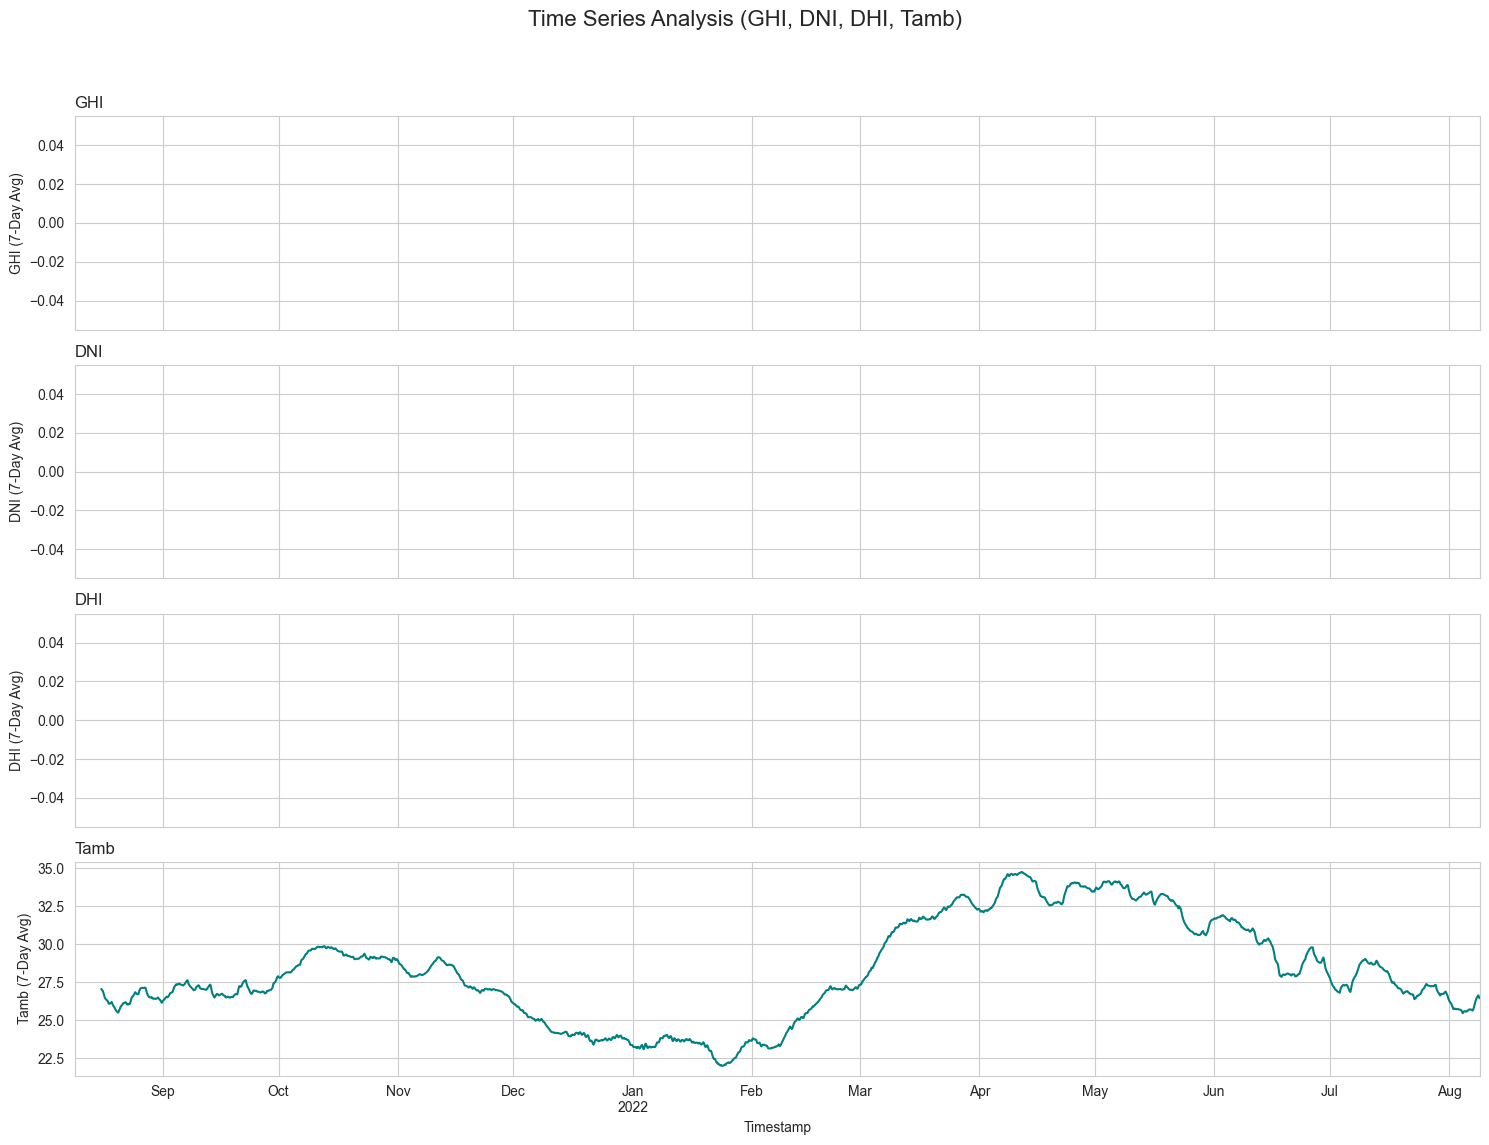

<Figure size 800x500 with 0 Axes>

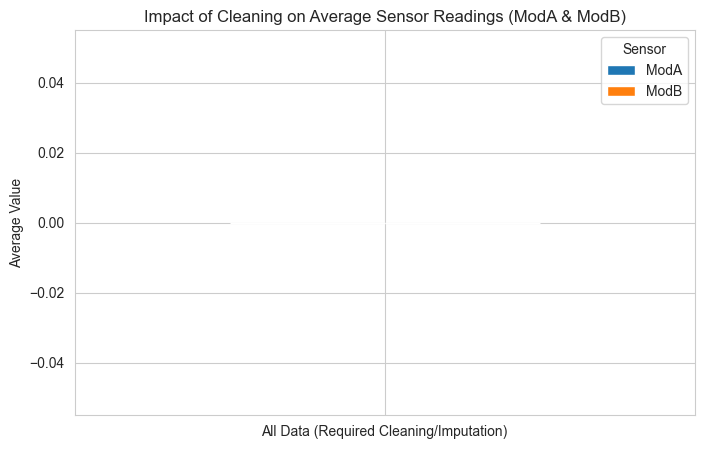

In [22]:
# --- Time Series Analysis: GHI, DNI, DHI, Tamb vs. Timestamp ---
variables = ['GHI', 'DNI', 'DHI', 'Tamb']
fig, axes = plt.subplots(len(variables), 1, figsize=(15, 12), sharex=True)
plt.suptitle('Time Series Analysis (GHI, DNI, DHI, Tamb)', fontsize=16)

for i, var in enumerate(variables):
    # CHANGED: 'H' is replaced with 'h' to remove the FutureWarning
    df_clean[var].resample('h').mean().rolling(window=7*24).mean().plot(ax=axes[i], color='teal')
    axes[i].set_title(var, loc='left')
    axes[i].set_ylabel(var + ' (7-Day Avg)')

plt.xlabel("Timestamp")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# --- Cleaning Impact: Pre/Post-Clean ModA & ModB ---
# (Using the robust code from the previous fix)
cleaning_impact = df_clean.groupby('Cleaning_Flag')[['ModA', 'ModB']].mean()

if len(cleaning_impact) == 2:
    cleaning_impact.index = ['Original/Clean Data', 'Cleaned/Imputed Data']
elif len(cleaning_impact) == 1:
    cleaning_impact.index = ['All Data (Required Cleaning/Imputation)']

plt.figure(figsize=(8, 5))
cleaning_impact.plot(kind='bar', figsize=(8, 5), rot=0)
plt.title('Impact of Cleaning on Average Sensor Readings (ModA & ModB)')
plt.ylabel('Average Value')
plt.legend(title='Sensor')
plt.show()

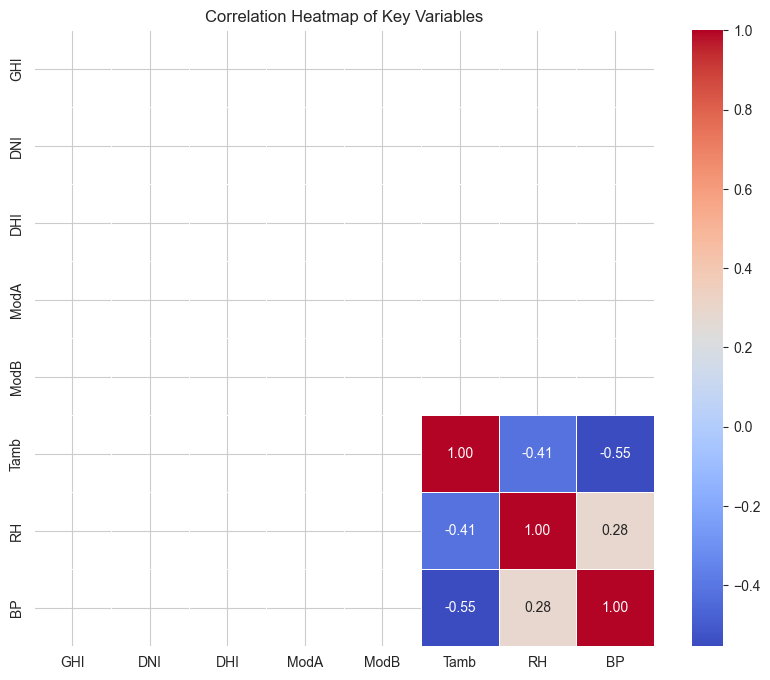

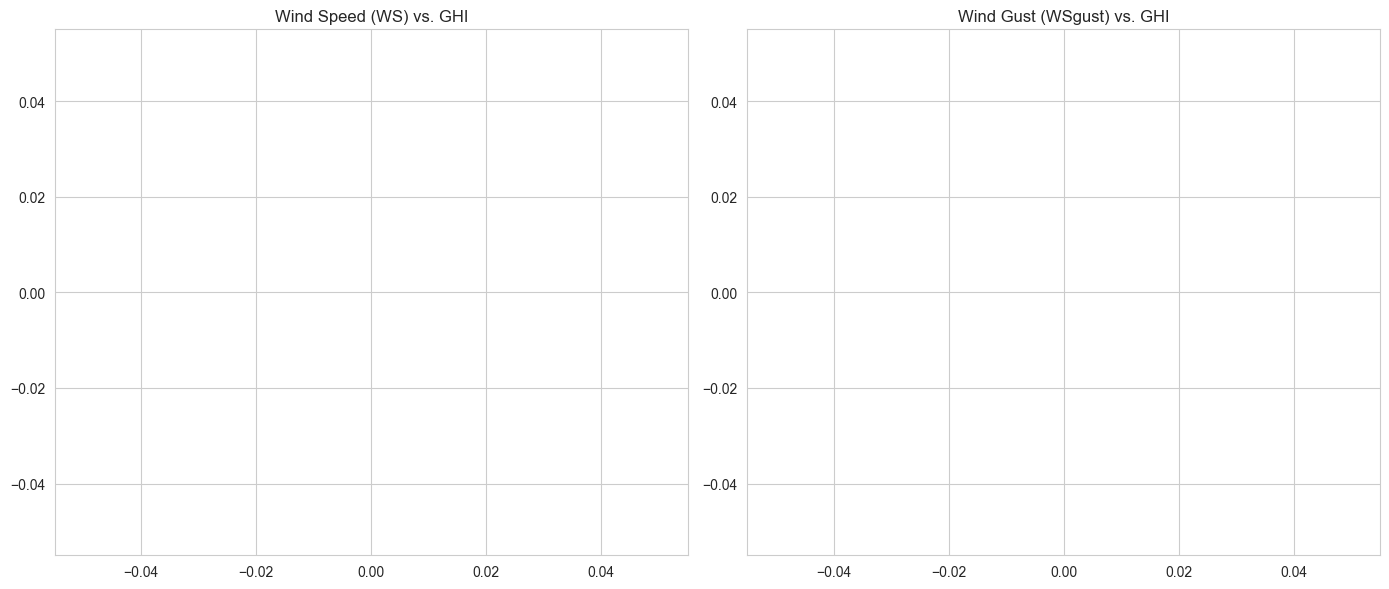

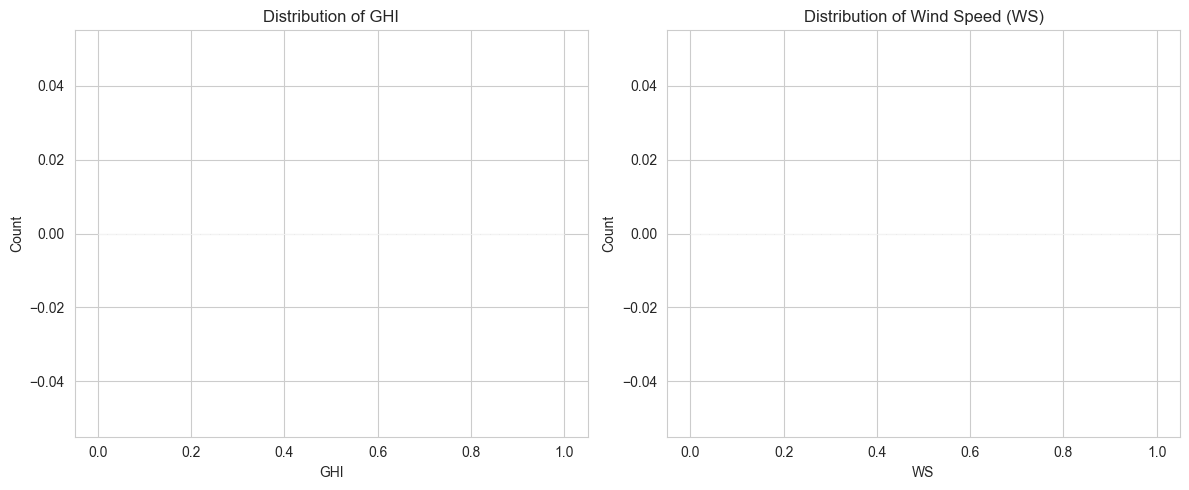

C:\Users\Home-User\AppData\Local\Temp\ipykernel_11260\4223351962.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Relative Humidity (RH)', bbox_to_anchor=(1.05, 1), loc='upper left')


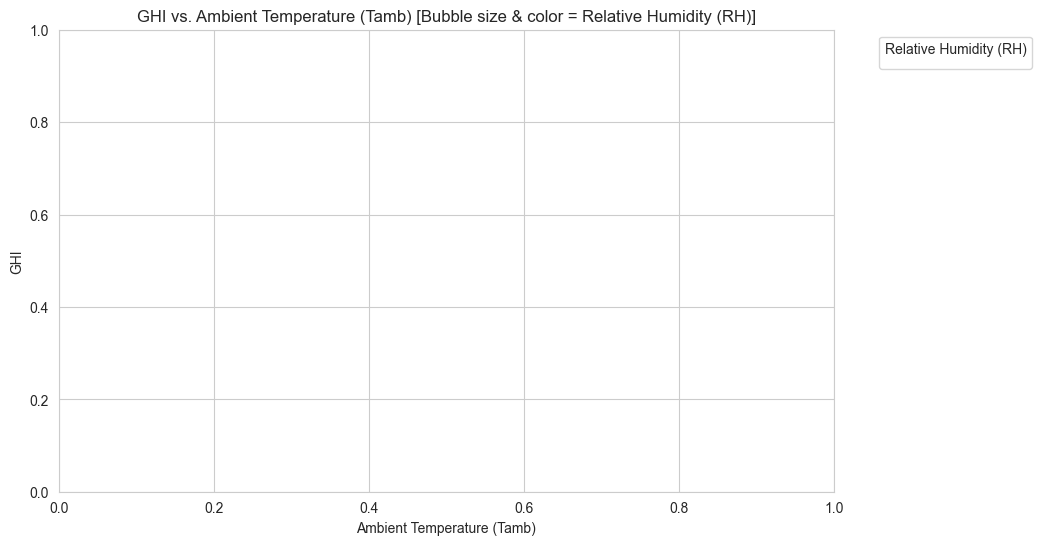

In [23]:
# Assuming df_clean is the clean, indexed DataFrame from Step 2.2

# --- Correlation Heatmap ---
corr_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'BP']
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Key Variables')
plt.show()



# --- Scatter Plot: WS, WSgust vs. GHI ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x='WS', y='GHI', data=df_clean, alpha=0.6, ax=axes[0])
axes[0].set_title('Wind Speed (WS) vs. GHI')

sns.scatterplot(x='WSgust', y='GHI', data=df_clean, alpha=0.6, ax=axes[1])
axes[1].set_title('Wind Gust (WSgust) vs. GHI')

plt.tight_layout()
plt.show()


# --- Histograms for GHI and WS (Distribution Analysis) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_clean['GHI'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of GHI')

sns.histplot(df_clean['WS'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Wind Speed (WS)')

plt.tight_layout()
plt.show()



# --- Bubble Chart: GHI vs. Tamb with bubble size = RH ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Tamb', y='GHI', size='RH', sizes=(20, 500), 
    data=df_clean, alpha=0.6, hue='RH', palette='viridis'
)
plt.title('GHI vs. Ambient Temperature (Tamb) [Bubble size & color = Relative Humidity (RH)]')
plt.xlabel('Ambient Temperature (Tamb)')
plt.ylabel('GHI')
plt.legend(title='Relative Humidity (RH)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()